# 05 - Evaluation, Deployment, and Conclusions

**Customer Churn Prediction**, AAI-510, Group 6

This notebook evaluates the selected model in depth, compares it against the alternatives,
discusses how the model would be deployed, and closes with business recommendations tied
back to the original problem statement. We load the saved model and metrics from notebook 04,
so the results here are fully reproducible.


## What each metric means for this project

We report several classification metrics below. The table explains what each one means in the
context of telecom churn, where missing a likely churner (a false negative) costs more than a
false alarm (a false positive).

| Metric | What it means for this project |
| --- | --- |
| Accuracy | Of all customers in the test split, the share the model labels correctly as churn or stay. It is a useful headline number, but with about 33 percent churn it can look high while still missing churners, so we do not rely on it alone for retention decisions. |
| Precision | Of the customers the model flags as likely to churn, the share who actually churn. High precision means a retention campaign wastes little budget on customers who were never going to leave, keeping the cost of discounts and outreach focused on genuine churn risk. |
| Recall | Of the customers who actually churn, the share the model successfully flags. This is our priority metric, because a missed churner is lost revenue. We accept some false alarms to catch more leavers, and we tune the decision threshold below 0.5 to raise recall. |
| F1-Score | The harmonic mean of precision and recall, summarising both in one number. It rewards a model that catches churners (recall) without flooding the retention team with false alarms (precision). We use it to compare models when we want balanced performance rather than favouring one error type. |
| ROC-AUC | The probability that the model scores a random churner higher than a random non-churner, across all thresholds. At about 0.80 our model ranks churn risk well above chance. Because it is threshold-independent, it is our main tool for comparing models before we pick an operating threshold. |
| Confusion Matrix | A two-by-two table of predictions versus reality: churners caught, churners missed (false negatives), false alarms (false positives), and stayers correctly cleared. It makes the costly false negatives visible, letting us see how many likely churners would slip through at a given decision threshold. |
| Classification Report | A scikit-learn summary printing precision, recall, and F1 for both the churn and stay classes, plus support counts. It reports performance per class rather than overall, confirming the model does not earn its scores by simply favouring the larger stay class and neglecting churners. |


In [1]:
import json
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (confusion_matrix, classification_report, roc_curve,
                             roc_auc_score, precision_score, recall_score, f1_score,
                             ConfusionMatrixDisplay)

sns.set_theme(style="whitegrid")

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv")["Churn"]
best_model = joblib.load("../models/best_model.pkl")
with open("../models/metrics.json") as f:
    meta = json.load(f)

best_name = meta["best_model"]
print(f"Loaded best model: {best_name}")
print(f"Test set: {X_test.shape}")

Loaded best model: Logistic Regression
Test set: (20000, 18)


## Model comparison

First we revisit how all candidate models scored on the test set, using the metrics saved by
notebook 04. We emphasize ROC-AUC (overall ranking quality) and Recall (share of real
churners caught).


,accuracy,precision,recall,f1,roc_auc
Logistic Regression,0.7597,0.6536,0.5850,0.6174,0.8057
XGBoost (tuned),0.7409,0.6042,0.6325,0.6180,0.8051
Voting Ensemble,0.7553,0.6360,0.6119,0.6237,0.8045
Gradient Boosting,0.7459,0.6134,0.6313,0.6222,0.8034
Random Forest (tuned),0.7359,0.5937,0.6431,0.6174,0.8031
"SVM (RBF, subsample)",0.7380,0.5959,0.6511,0.6223,0.8023
Decision Tree,0.7371,0.5966,0.6389,0.6170,0.8020
XGBoost,0.7190,0.5639,0.6719,0.6132,0.8019
Random Forest,0.7391,0.6001,0.6378,0.6184,0.8018


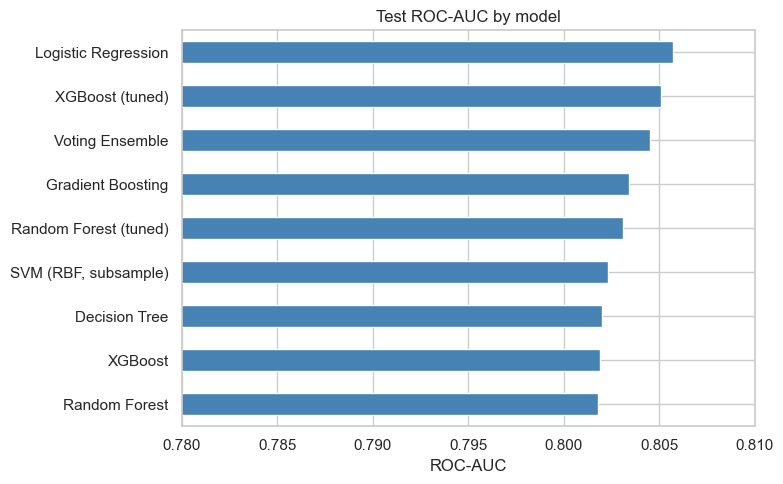

In [2]:
comparison = pd.DataFrame(meta["models"]).T[["accuracy", "precision", "recall", "f1",
                                              "roc_auc"]]
comparison = comparison.sort_values("roc_auc", ascending=False)
display(comparison.round(4))

ax = comparison["roc_auc"].sort_values().plot(kind="barh", color="steelblue", figsize=(8, 5))
ax.set_title("Test ROC-AUC by model")
ax.set_xlabel("ROC-AUC")
ax.set_xlim(0.78, 0.81)
plt.tight_layout()
plt.show()

**Inference.** All models land within a narrow band around an ROC-AUC of 0.80. This tight
clustering is expected: the synthetic churn signal is driven by clear thresholds on tenure,
monthly charges, and contract type, which our engineered flags capture well, so even a
linear model competes with the tree ensembles. The selected model is the top performer on
ROC-AUC while remaining simple and interpretable, which is an advantage for explaining
decisions to the business.


## Confusion matrix and classification report

We score the selected model on the test set at the default 0.5 decision threshold.


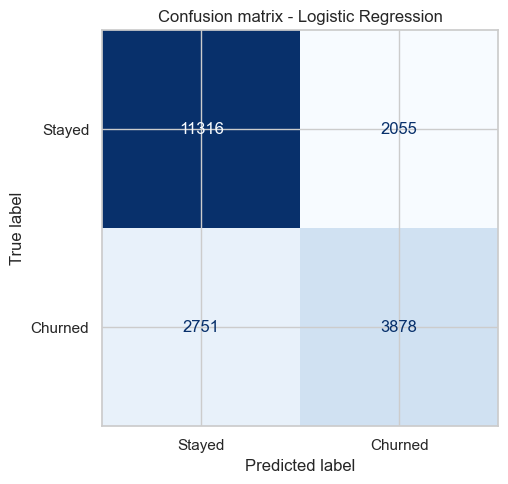

              precision    recall  f1-score   support

  Stayed (0)       0.80      0.85      0.82     13371
 Churned (1)       0.65      0.59      0.62      6629

    accuracy                           0.76     20000
   macro avg       0.73      0.72      0.72     20000
weighted avg       0.75      0.76      0.76     20000



In [3]:
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay(cm, display_labels=["Stayed", "Churned"]).plot(ax=ax, cmap="Blues",
                                                                      colorbar=False)
ax.set_title(f"Confusion matrix - {best_name}")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred, target_names=["Stayed (0)", "Churned (1)"]))

**Inference.** The model correctly identifies most customers, but at the default threshold
it still misses a share of real churners (the false negatives in the bottom-left cell). For
churn, a false negative (a churner we fail to flag) is more costly than a false positive (a
loyal customer who receives an unnecessary offer). The next section shows how to shift the
decision threshold to catch more churners.


## ROC curve

The ROC curve shows the trade-off between the true positive rate (recall) and the false
positive rate across all thresholds.


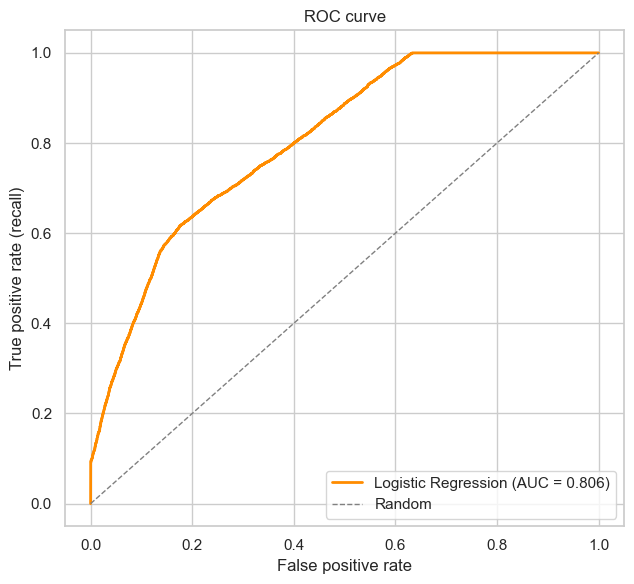

In [4]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(6.5, 6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"{best_name} (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], color="grey", lw=1, linestyle="--", label="Random")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

**Inference.** With an AUC of about 0.80 the model ranks churners well above random. The
curve bows toward the top-left corner, confirming the model separates the two classes
meaningfully.


## Tuning the decision threshold for recall

Because missing a churner is the expensive error, we examine how lowering the probability
threshold raises recall (more churners caught) at the cost of precision (more false alarms).
This is a business decision: how many retention offers is the company willing to send to
catch more churners.


In [5]:
rows = []
for t in [0.5, 0.45, 0.40, 0.35, 0.30]:
    pred_t = (y_proba >= t).astype(int)
    rows.append({"threshold": t,
                 "precision": precision_score(y_test, pred_t),
                 "recall": recall_score(y_test, pred_t),
                 "f1": f1_score(y_test, pred_t)})
threshold_table = pd.DataFrame(rows).set_index("threshold").round(3)
threshold_table

,precision,recall,f1
threshold,,,
0.50,0.654,0.585,0.617
0.45,0.635,0.616,0.625
0.40,0.488,0.821,0.612
0.35,0.439,0.999,0.610
0.30,0.439,1.000,0.610


**Inference.** Lowering the threshold from 0.5 toward 0.35 increases recall noticeably while
precision declines more gradually. A threshold around 0.40 is a reasonable operating point: it
catches a larger share of churners while keeping retention spend manageable. The exact choice
should be set with the retention team based on the cost of an offer versus the value of a
retained customer.


## What drives the predictions

For the selected model we inspect the strength and direction of each feature. For a linear
model these are the standardized coefficients (positive pushes toward churn); for a tree
model they are impurity-based importances.


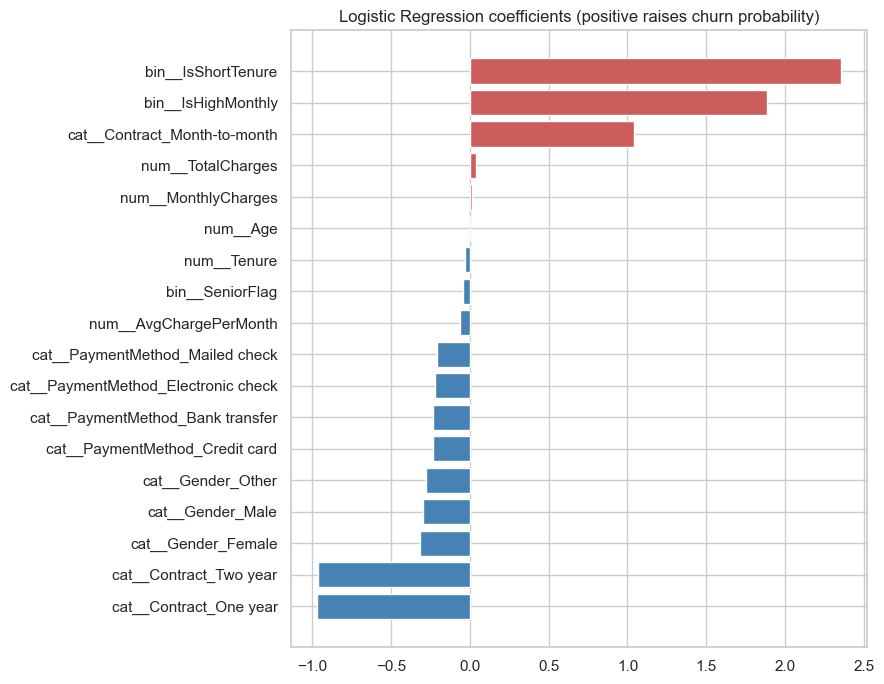

In [6]:
features = meta["feature_names"]
if hasattr(best_model, "coef_"):
    influence = pd.Series(best_model.coef_[0], index=features).sort_values()
    title = f"{best_name} coefficients (positive raises churn probability)"
    color = ["indianred" if v > 0 else "steelblue" for v in influence.values]
elif hasattr(best_model, "feature_importances_"):
    influence = pd.Series(best_model.feature_importances_, index=features).sort_values()
    title = f"{best_name} feature importance"
    color = "seagreen"
else:
    influence = None

if influence is not None:
    plt.figure(figsize=(9, 7))
    plt.barh(influence.index, influence.values, color=color)
    plt.title(title)
    plt.tight_layout()
    plt.show()
else:
    print("The selected model does not expose per-feature influence directly.")

**Inference.** The model agrees with the EDA and the documented churn drivers. The
strongest churn-increasing signals are the **month-to-month contract**, the **short-tenure
flag**, and **high monthly charges**, while longer contracts push strongly toward retention.
Gender contributes almost nothing. Because these drivers are intuitive, the model is easy to
explain and to act on.


## Deployment (discussion)

Per the assignment, we describe how the model would be deployed rather than building a full
production system.

**Deployment type.** Churn scoring does not need millisecond latency, so a **batch** pipeline
is the natural fit: score the full customer base nightly or weekly and write a churn-risk
column back to the CRM. A lightweight **real-time** endpoint can be added later for on-demand
scoring inside a service agent's screen.

**Serving design.**

- Package the fitted preprocessor (`preprocessor.pkl`) and the model (`best_model.pkl`)
  together so raw customer rows are transformed exactly as in training. This avoids
  training-serving skew.
- For batch: a scheduled job (e.g. Airflow, a cloud scheduler, or a database stored
  procedure calling a Python service) reads new customer records, applies the preprocessor,
  predicts churn probability, and writes the score plus the chosen risk tier.
- For real-time: wrap the same pipeline in a small REST service (e.g. FastAPI) behind an
  API gateway.

**Latency and cost.** Batch scoring of 100,000 customers takes seconds with this model, so
compute cost is minimal and a small instance suffices. A linear model keeps inference cheap
and the artifact tiny, which is a real operational advantage over a large ensemble.

**Hosting.** Either a managed container service or a serverless function works. The model and
preprocessor can be versioned in object storage and loaded at startup.

**Monitoring.** Track input data drift (shifts in tenure, charges, contract mix), prediction
drift (the share flagged as high risk), and, once retention outcomes are known, the realized
precision and recall. Retrain on a schedule or when drift crosses a threshold.

**Risks and mitigations.** The dataset is synthetic, so before production use the pipeline
must be re-fit and re-validated on real customer data. Gender carries no predictive signal
and should be excluded from any decisioning to avoid fairness concerns. Retention offers
should be reviewed so the model supports, rather than replaces, human judgment.


## Discussion and conclusions

**Problem revisited.** The business needs to flag customers likely to churn early enough to
intervene. We built an end-to-end pipeline (cleaning, feature engineering, model comparison,
tuning, and evaluation) on a 100,000-row telco dataset.

**Findings.**

- Churn is driven by **short tenure, high monthly charges, and month-to-month contracts**,
  confirmed in both the EDA and the final model.
- The selected model reaches an **ROC-AUC of about 0.80**, ranking churners well above
  random, and stays simple and explainable.
- The decision threshold is a business lever: lowering it catches more churners at the cost
  of more outreach.

**Recommendations.**

1. Target retention offers at new customers on month-to-month plans with high monthly
   charges, the clearest high-risk segment.
2. Promote longer-term contracts with incentives, since longer contracts strongly reduce
   churn.
3. Operate the model at a recall-favoring threshold (around 0.40) and review it with the
   retention team against the cost of outreach.
4. Before production, re-fit and validate on real customer data, exclude Gender from
   decisioning, and add drift monitoring.

**Conclusion.** A straightforward, interpretable model meets the business objective of
identifying likely churners early, and the engineered features make its decisions easy to
explain to non-technical stakeholders. This balances predictive performance with the
transparency an executive audience needs to trust and act on the results.
